In [3]:
import pandas as pd
import numpy as np
import trackpy as tp

import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("positions_old.csv")

print(df.head())

positions_df = pd.read_csv("positions_old.csv")

trajectories = tp.link(positions_df, search_range=5, memory=5)
print(positions_df["frame"].unique())
trajectories.head()
positions_df["frame"].max()   # must be >1

Frame 199: 831 trajectories present.
[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139.
 140. 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153.
 154. 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167.
 168. 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181.
 182. 183. 184. 185. 186. 187. 188. 189.

199.0

In [5]:
df = df.sort_values(["index", "frame"])

In [6]:
def compute_msd_tp(df):
    msd_list = []

    for pid, group in df.groupby("particle"):
        group = group.sort_values("frame")
        coords = group[["x", "y"]].values
        n = len(coords)

        if n < 2:
            continue

        for lag in range(1, n):
            disp = coords[lag:] - coords[:-lag]
            sq_disp = (disp**2).sum(axis=1)

            msd_list.append(pd.DataFrame({
                "lag": lag,
                "msd": sq_disp
            }))

    msd_df = pd.concat(msd_list)
    return msd_df.groupby("lag")["msd"].mean().reset_index()

In [7]:
print(positions_df["frame"].nunique())   # must be >1
print(len(trajectories["particle"].unique()))
print(trajectories.groupby("particle").size().describe())
msd = compute_msd_tp(trajectories)
msd.head()

200
4531
count    4531.000000
mean       37.216729
std        55.190617
min         1.000000
25%         3.000000
50%        11.000000
75%        43.500000
max       200.000000
dtype: float64


,lag,msd
0,1,0.313140
1,2,0.526200
2,3,0.721144
3,4,0.909217
4,5,1.098588


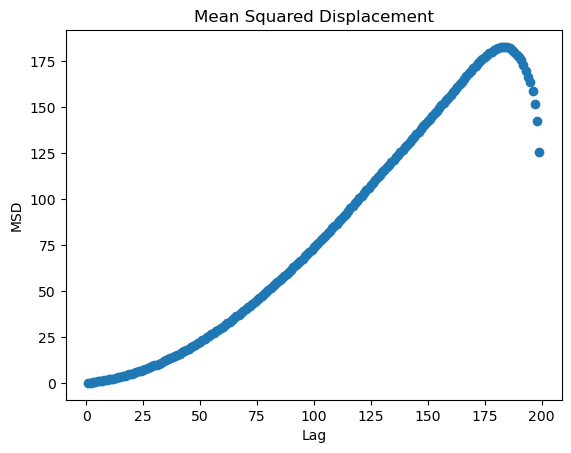

In [11]:
msd.head()
plt.figure()
plt.scatter(msd["lag"], msd["msd"])
plt.xlabel("Lag")
plt.ylabel("MSD")
plt.title("Mean Squared Displacement")
plt.show()

In [ ]:
print(df.head())
print(df.columns)
print(df.groupby("index").size().head())
df.groupby("index").size().value_counts()

   index  frame           x         y
0      1    0.0  279.000000  0.500000
1      2    0.0   10.000000  3.000000
2      3    0.0  297.500000  3.000000
3      4    0.0   53.000000  4.500000
4      5    0.0  274.333333  4.666667
Index(['index', 'frame', 'x', 'y'], dtype='object')
index
1    1
2    1
3    1
4    1
5    1
dtype: int64


1    168629
Name: count, dtype: int64

In [13]:
import pandas as pd

def zero_trajectories(df):
    df = df.sort_values(["particle", "frame"])

    # subtract initial position per particle
    df[["x0", "y0"]] = df.groupby("particle")[["x", "y"]].transform("first")
    df["x_rel"] = df["x"] - df["x0"]
    df["y_rel"] = df["y"] - df["y0"]

    return df

traj_rel = zero_trajectories(trajectories)

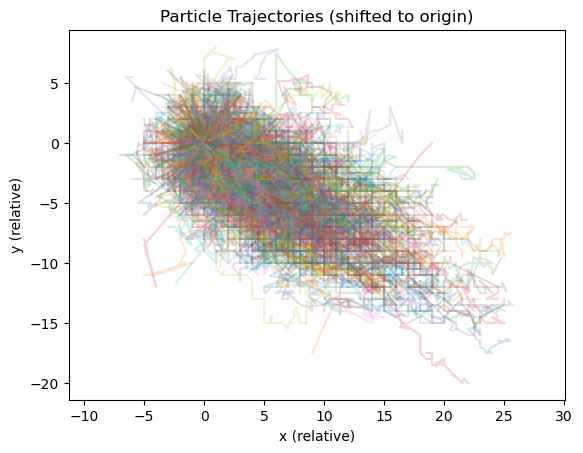

In [14]:
import matplotlib.pyplot as plt

plt.figure()

for pid, group in traj_rel.groupby("particle"):
    plt.plot(group["x_rel"], group["y_rel"], alpha=0.2)

plt.xlabel("x (relative)")
plt.ylabel("y (relative)")
plt.title("Particle Trajectories (shifted to origin)")
plt.axis("equal")
plt.show()

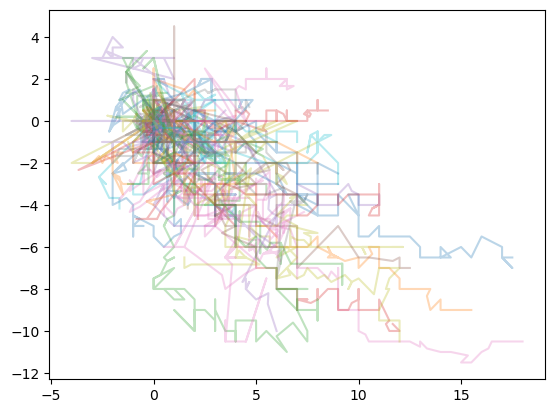

In [15]:
sample_ids = traj_rel["particle"].drop_duplicates().sample(200)

for pid in sample_ids:
    g = traj_rel[traj_rel["particle"] == pid]
    plt.plot(g["x_rel"], g["y_rel"], alpha=0.3)

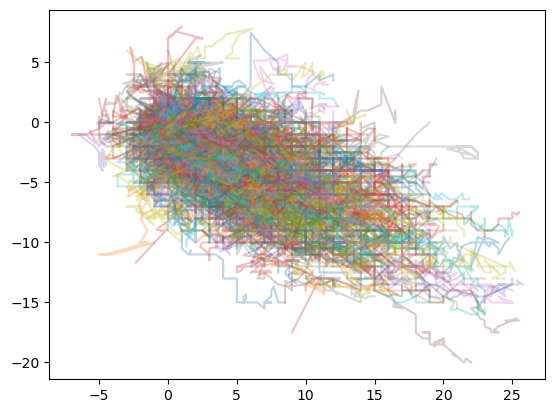

In [34]:
valid = traj_rel.groupby("particle").filter(lambda g: len(g) > 50)
group = group.interpolate()
for pid, g in valid.groupby("particle"):
    plt.plot(g["x_rel"], g["y_rel"], alpha=0.3)

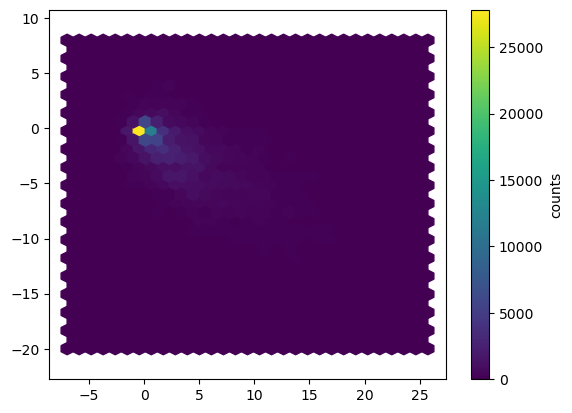

In [41]:
plt.hexbin(traj_rel["x_rel"], traj_rel["y_rel"], gridsize=30)

plt.colorbar(label="counts")
plt.axis("equal")
plt.show()

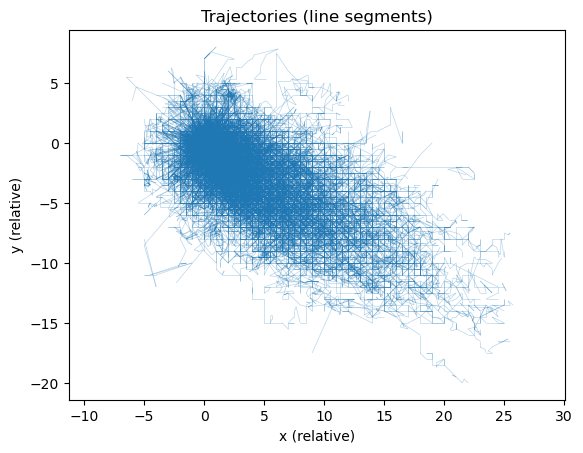

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

plt.figure()

segments = []
plt.grid(False)
for pid, group in traj_rel.groupby("particle"):
    group = group.sort_values("frame")
    x = group["x_rel"].values
    y = group["y_rel"].values

    if len(x) < 2:
        continue

    pts = np.column_stack([x, y])
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    segments.append(segs)

segments = np.concatenate(segments)

lc = LineCollection(segments, linewidths=0.5, alpha=0.3)
plt.gca().add_collection(lc)

plt.xlabel("x (relative)")
plt.ylabel("y (relative)")
plt.title("Trajectories (line segments)")
plt.axis("equal")
plt.show()  

In [ ]:
dx = trajectories.groupby("particle")["x"].diff()
dy = trajectories.groupby("particle")["y"].diff()

### ADD code for how to check for stationary dy and dx with a change in the other 

168629


In [31]:
import numpy as np

disp = np.sqrt(dx**2 + dy**2)
print(disp.describe())

count    164097.000000
mean          0.310818
std           0.465302
min           0.000000
25%           0.000000
50%           0.000000
75%           0.500000
max           5.000000
dtype: float64


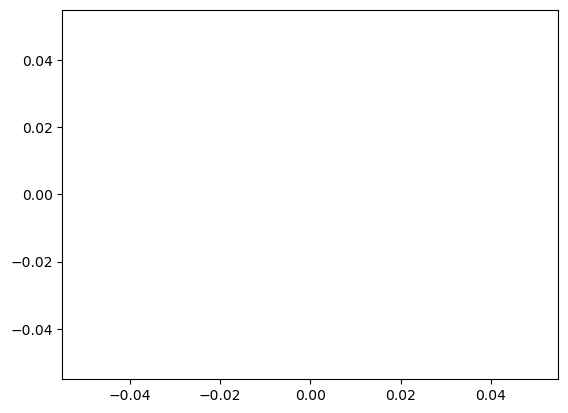

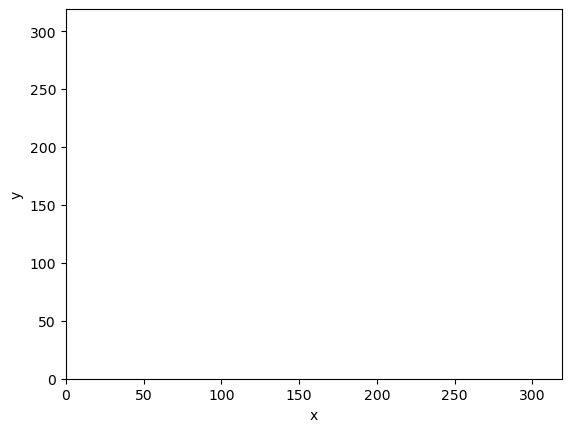

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ensure sorted
traj = trajectories.sort_values("frame")
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()
scat = ax.scatter([], [])

frames = trajectories["frame"].unique()

def update(frame):
    data = trajectories[trajectories["frame"] == frame]
    scat.set_offsets(data[["x", "y"]].values)
    return scat,

anim = FuncAnimation(fig, update, frames=frames, interval=50)

plt.show()
frames = traj["frame"].unique()

fig, ax = plt.subplots()
scat = ax.scatter([], [])

ax.set_xlim(traj["x"].min(), traj["x"].max())
ax.set_ylim(traj["y"].min(), traj["y"].max())
ax.set_xlabel("x")
ax.set_ylabel("y")

def update(frame):
    data = traj[traj["frame"] == frame]
    scat.set_offsets(data[["x", "y"]].values)
    ax.set_title(f"Frame {frame}")
    return scat,

anim = FuncAnimation(fig, update, frames=frames, interval=50)

plt.show()

/usr/lib/python3/dist-packages/matplotlib/animation.py:880: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
/usr/lib/python3/dist-packages/matplotlib/animation.py:880: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


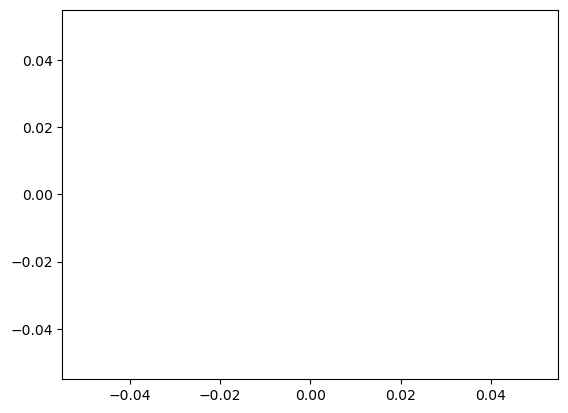

In [39]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
scat = ax.scatter([], [])

def update(frame):
    data = trajectories[trajectories["frame"] == frame]
    scat.set_offsets(data[["x", "y"]].values)
    return scat,

anim = FuncAnimation(fig, update, frames=trajectories["frame"].unique(), interval=50)

HTML(anim.to_jshtml())